<p style="color: #05402B; font-size: 32px; font-weight: bold; text-align: center; margin-top: 20px;"> 
Restaurantes de Madrid
</p>
<p style="color: #000000; font-size: 24px; text-align: center; margin-bottom: 20px;">
Sistema inteligente de análisis de reseñas para el diagnóstico y benchmarking competitivo
</p>


# 1. Comprensión de los datos y EDA inicial

## Importación de librerías

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pandera.pandas as pa

## 1.1. Carga de los datos

In [2]:
# Cargar datos
DATA_PATH = Path('data')

reviews_df = pd.read_pickle(DATA_PATH / 'reviews.pkl')
items_df = pd.read_pickle(DATA_PATH / 'items.pkl')


In [3]:
# Normalizar nombres
for df in [reviews_df, items_df]:
    df.columns = df.columns.str.replace(
        r"(?<!^)(?=[A-Z])", "_", regex=True
    ).str.lower()

In [4]:
# Mostrar muestras
display(reviews_df.head())
display(items_df.head())

,review_id,user_id,item_id,title,text,date,rating,language,images,url
0,881374404,74B2D6F62DB1CEC358822079728F8317,20112202,Cena en familia,"Pedimos una pizza para cenar, mitad barbacoa m...",2023-03-07,50,es,[https://media-cdn.tripadvisor.com/media/photo...,https://www.tripadvisor.com/ShowUserReviews-g1...
1,872226520,1B3559478B9FF8A52A552BA99AC6F00E,20112202,Que asco de restaurante,"Better pizza, mejor ponte a hacer pan que tien...",2022-12-19,10,es,[],https://www.tripadvisor.com/ShowUserReviews-g1...
2,850451467,FE5E99DC6572BB56B2D1D893BC13A392,20112202,"Pizzas distintas, riquísimas","Pizza de rabo de toro, conejo al ajillo,... so...",2022-07-28,50,es,[https://media-cdn.tripadvisor.com/media/photo...,https://www.tripadvisor.com/ShowUserReviews-g1...
3,810574583,9E85C6C3DA1C0498B1EEEE9A3A833A99,20112202,ONE OF THE BEST PIZZAS,"pizza rica y distinta. calidad muy alta, el sa...",2021-09-18,50,es,[],https://www.tripadvisor.com/ShowUserReviews-g1...
4,757187287,5FB02D459F27ECD91CB38AC3CCD92B79,20112202,Muy buenas pizzas. Tienen,Muy buenas pizzas. Tienen de varios tamaños pe...,2020-06-10,50,es,[],https://www.tripadvisor.com/ShowUserReviews-g1...


,item_id,name,city,price_interval,url,rating,type
0,20112202,66's Bar&pizzas,Madrid,$$ - $$$,https://www.tripadvisor.com/Restaurant_Review-...,45,"[Italian, Pizza]"
1,17763117,80's Coffee,Madrid,,https://www.tripadvisor.com/Restaurant_Review-...,20,"[Coffee & Tea, Cafe]"
2,11859217,84,Madrid,$$ - $$$,https://www.tripadvisor.com/Restaurant_Review-...,45,"[Mediterranean, Spanish]"
3,11862880,A' La Broaster,Madrid,$,https://www.tripadvisor.com/Restaurant_Review-...,50,[Fast Food]
4,10276639,A' Lareira,Madrid,,https://www.tripadvisor.com/Restaurant_Review-...,30,[Spanish]


## 1.2. Descripción de los datasets

<h2 style="color:#05402B; text-align:center;">Diccionario de datos</h2>

<table width="100%" border="0" cellspacing="0" cellpadding="0" style="width:100%; border:none; border-collapse:collapse; margin-bottom:30px;">
<tr>
<td width="47%" style="width:47%; padding:0; vertical-align:top; border:none;">
<table width="100%" cellspacing="0" cellpadding="0" style="width:100%; border-collapse:collapse;">
<thead>
<tr>
<th colspan="2" style="padding:12px; background-color:#05402B; color:white; text-align:left; border:1px solid #2F75B5;">Review Information</th>
</tr>
<tr style="background-color:#D9EAF7;">
<th style="width:27%; padding:9px; text-align:left; border:1px solid #B4C6E7;">Variable</th>
<th style="padding:9px; text-align:left; border:1px solid #B4C6E7;">Description</th>
</tr>
</thead>
<tbody>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>review_id</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Unique identifier for each review.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>user_id</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Identifier of the user who wrote the review.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>item_id</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Identifier of the restaurant associated with the review.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>title</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Title summarizing the user's opinion.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>text</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Full text describing the user's experience.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>date</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Date when the review was published.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>rating</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Rating from 0 to 50, where 50 represents the highest satisfaction.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>language</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Language in which the review was written.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>images</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">List of URLs pointing to images uploaded by the user, when available.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>url</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Link to the full review on TripAdvisor.</td>
</tr>
</tbody>
</table>
</td>
<td width="6%" style="width:6%; padding:0; border:none; background-color:#FFFFFF;">&nbsp;</td>
<td width="47%" style="width:47%; padding:0; vertical-align:top; border:none;">
<table width="100%" cellspacing="0" cellpadding="0" style="width:100%; border-collapse:collapse;">
<thead>
<tr>
<th colspan="2" style="padding:12px; background-color:#05402B; color:white; text-align:left; border:1px solid #2F75B5;">Restaurant Information (Items)</th>
</tr>
<tr style="background-color:#D9EAF7;">
<th style="width:30%; padding:9px; text-align:left; border:1px solid #B4C6E7;">Variable</th>
<th style="padding:9px; text-align:left; border:1px solid #B4C6E7;">Description</th>
</tr>
</thead>
<tbody>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>item_id</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Unique identifier for each restaurant.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>name</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Restaurant name.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>city</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">City where the restaurant is located.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>price_interval</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Restaurant price range.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>url</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Link to the restaurant's TripAdvisor page.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>rating</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Average rating received by the restaurant.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>type</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">List of cuisine types, such as [Spanish, Mediterranean].</td>
</tr>
</tbody>
</table>
</td>
</tr>
</table>

<table width="100%" cellspacing="0" cellpadding="0" style="width:100%; border-collapse:collapse;">
<thead>
<tr>
<th colspan="2" style="padding:12px; background-color:#05402B; color:white; text-align:left; border:1px solid #2F75B5;">User Information</th>
</tr>
<tr style="background-color:#D9EAF7;">
<th style="width:30%; padding:9px; text-align:left; border:1px solid #B4C6E7;">Variable</th>
<th style="padding:9px; text-align:left; border:1px solid #B4C6E7;">Description</th>
</tr>
</thead>
<tbody>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>user_id</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Unique hashed identifier for each user.</td>
</tr>
<tr style="background-color:#F2F6FA;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>name</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">Display name or username.</td>
</tr>
<tr style="background-color:#FFFFFF;">
<td style="padding:9px; border:1px solid #B4C6E7;"><strong>location</strong></td>
<td style="padding:9px; border:1px solid #B4C6E7;">User's location, including city and country.</td>
</tr>
</tbody>
</table>

`User Information` se excluye porque no aporta al objetivo.

## 1.3. Tipología y rol de las variables

In [5]:
# Revisar tipos
print(f"Información de Reseñas")
reviews_df.info()
print(f"\nInformación de Items")
items_df.info()

Información de Reseñas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347959 entries, 0 to 1347958
Data columns (total 10 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   review_id  1347959 non-null  int64 
 1   user_id    1347959 non-null  object
 2   item_id    1347959 non-null  int64 
 3   title      1347959 non-null  object
 4   text       1347959 non-null  object
 5   date       1347959 non-null  object
 6   rating     1347959 non-null  int64 
 7   language   1347959 non-null  object
 8   images     1347959 non-null  object
 9   url        1347959 non-null  object
dtypes: int64(3), object(7)
memory usage: 102.8+ MB

Información de Items
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11544 entries, 0 to 11543
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   item_id         11544 non-null  int64 
 1   name            11544 non-null  object
 2   city     

**Rol y tipo de las variables**

**Reviews**

- `review_id`, `user_id` e `item_id`: identificadores en formato string.
- `title` y `text`: texto para NLP en formato string.
- `date`: variable temporal en formato datetime.
- `rating`: puntuación codificada de 10 a 50.
- `language`: variable categórica.
- `images` y `url`: variables excluidas.

**Items**

- `item_id`: clave de unión en formato string.
- `name`: nombre del restaurante en formato string.
- `price_interval`: variable categórica.
- `rating`: puntuación codificada de 10 a 50.
- `type`: variable categórica multietiqueta conservada como object.
- `city` y `url`: variables excluidas.


**Copia de Datasets para la depuración de datos**

Se crean copias, se eliminan variables fuera del alcance, se aclaran los nombres y se corrigen los tipos.


In [6]:
# Copiar datasets
# Se eliminan columnas innecesarias
# Se renombran variables para mejor claridad

reviews = (
    reviews_df
    .drop(columns=['images', 'url'])
    .rename(columns={'rating': 'review_rating'})
    .copy()
)


items = (
    items_df
    .drop(columns=['url', 'city'])
    .rename(columns={'rating': 'restaurant_rating'})
    .copy()
)

In [7]:
# Corregir tipos

# Reviews
reviews = reviews.astype({
    'review_id': 'string',
    'user_id': 'string',
    'item_id': 'string',
    'title': 'string',
    'text': 'string',
    'review_rating': 'Int64',
    'language': 'category'
})

reviews['date'] = pd.to_datetime(
    reviews['date'],
    format='%Y-%m-%d',
    errors='coerce'
)

# Items
items = items.astype({
    'item_id': 'string',
    'name': 'string',
    'price_interval': 'category',
    'restaurant_rating': 'Int64'
})

In [8]:
# Creación de diccionario de DataFrames
datasets = {
    'reviews': reviews,
    'items': items
}

Los tipos se corrigen antes de explorar. La depuración de valores se realiza en la sección 2.


### Exploración de valores únicos

Se revisan valores únicos para detectar códigos inválidos, valores fuera de rango, categorías, duplicados y ausencias.


In [9]:
# Resumir valores únicos
unique_summary = []

# For loop para mostrar valores únicos
for dataset_name, dataframe in datasets.items():
    for column_name in dataframe.columns:
        values = dataframe[column_name].astype("string")
        value_counts = values.value_counts(dropna=False).sort_index()
        unique_summary.append({
            "dataset": dataset_name,
            "variable": column_name,
            "unique_values": values.nunique(dropna=True),
            "values": value_counts.to_dict()
        })

# Creación de DataFrame
unique_summary = pd.DataFrame(unique_summary)
unique_summary

,dataset,variable,unique_values,values
0,reviews,review_id,1339351,"{'100002321': 1, '100002841': 1, '100005607': ..."
1,reviews,user_id,629201,"{'-1': 6123, '00001B21D9CFBF7BE3BFCC3FE152C4EC..."
2,reviews,item_id,10109,"{'10006904': 8, '10007089': 46, '10021151': 74..."
3,reviews,title,799215,"{'': 14, '!': 5, '! ALCACHOFAS AL PODER ¡': 1,..."
4,reviews,text,1338757,{'! If you are gluten free- this is the place ...
5,reviews,date,5562,"{'2002-11-11': 1, '2003-04-29': 1, '2003-10-12..."
6,reviews,review_rating,5,"{'10': 105657, '20': 72346, '30': 153771, '40'..."
7,reviews,language,27,"{'ar': 180, 'cs': 123, 'da': 1587, 'de': 9497,..."
8,items,item_id,11468,"{'10006904': 1, '10007089': 1, '10021151': 1, ..."
9,items,name,10327,"{'+Kcopas': 1, '+qdelicia': 1, '...hasta Los A..."


**Revisión de valores únicos**

**Reviews**

- `review_id`: 8,608 identificadores reutilizados; se revisan como duplicados.
- `user_id`: 6,123 registros con `-1`, correspondiente a usuarios no identificados.
- `item_id`: se repite porque un restaurante puede tener varias reseñas.
- `title`: 14 entradas vacías.
- `text`: los textos repetidos no demuestran filas duplicadas.
- `date`: 5,562 fechas distintas; se revisan rango y continuidad.
- `review_rating`: puntuaciones 10, 20, 30, 40 y 50.
- `language`: 27 idiomas; la selección se justifica después.

**Items**

- `item_id`: 76 identificadores reutilizados; debe quedar único antes del `merge many_to_one`.
- `name`: puede repetirse entre restaurantes distintos.
- `price_interval`: 3,651 valores faltantes.
- `restaurant_rating`: cinco valores `-10` fuera de rango y 1,364 valores `0` por revisar.
- `type`: 825 combinaciones; se aplicará `explode()` para analizar cada especialidad.


### Exploración gráfica de variables

In [10]:
# Funciones auxiliares para gráficos
def format_axis(ax, title, xlabel='', ylabel='', grid_axis='y'):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.grid(axis=grid_axis, alpha=0.5)


def add_bar_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, padding=3)

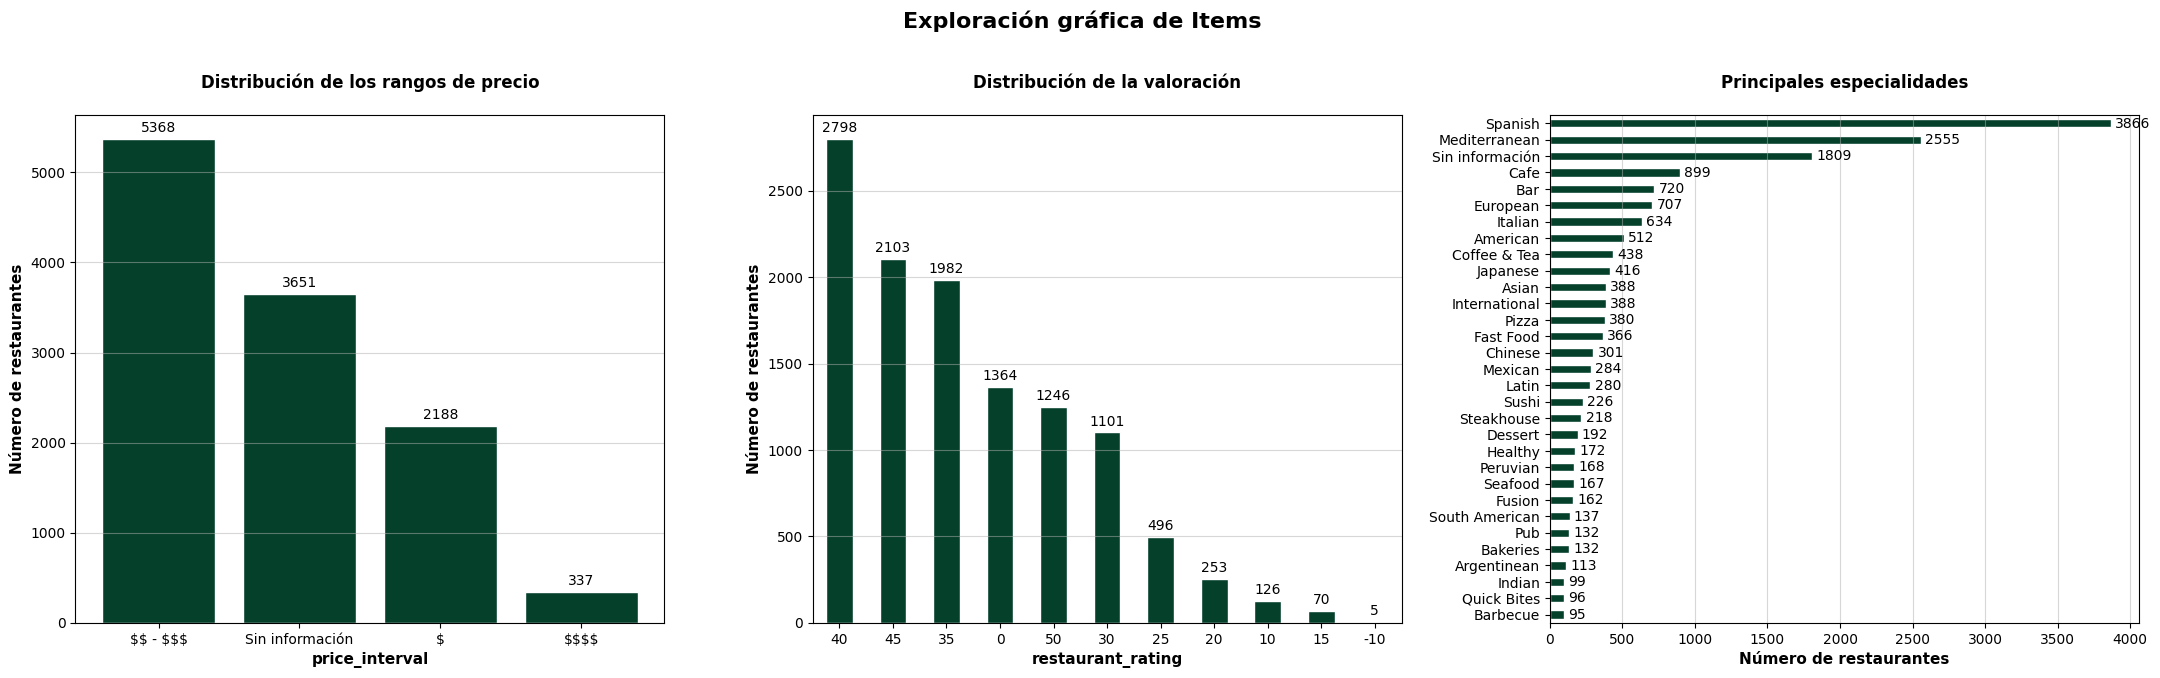

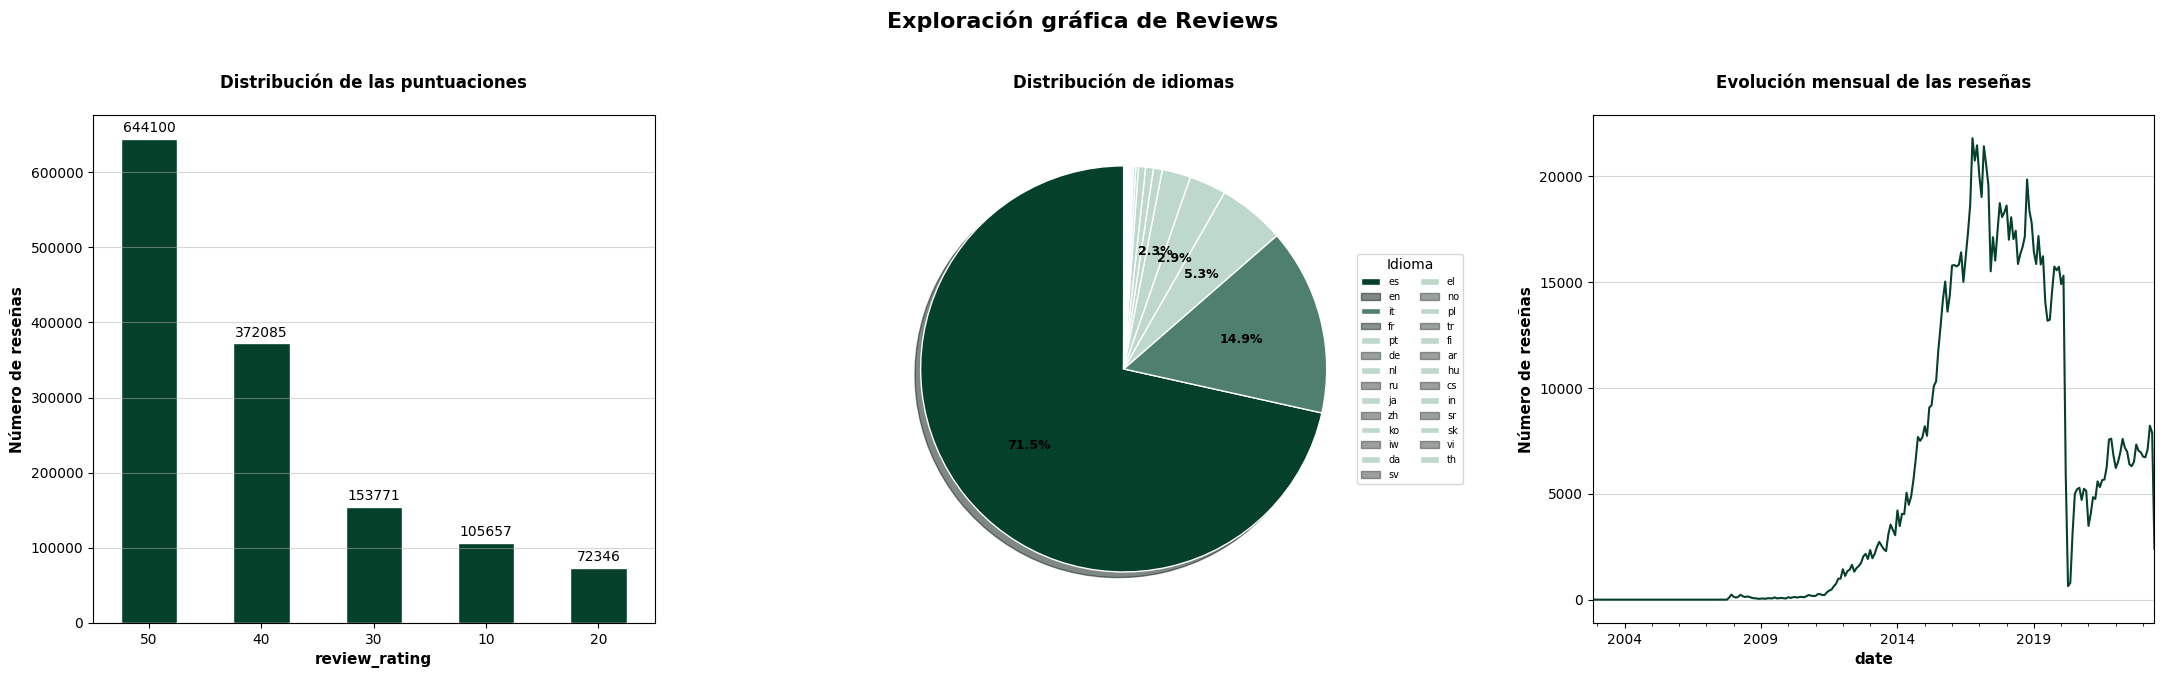

In [11]:

# Exploración gráfica de Items
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Rangos de precio
price_counts = (
    items['price_interval']
    .astype('string')
    .str.strip()
    .replace('', 'Sin información')
    .fillna('Sin información')
    .value_counts()
)

price_labels = [str(value).replace('$', r'\$') for value in price_counts.index]

axes[0].bar(
    price_labels,
    price_counts.values,
    color='#05402B',
    edgecolor='white'
)

format_axis(
    axes[0],
    'Distribución de los rangos de precio',
    'price_interval',
    'Número de restaurantes'
)
add_bar_labels(axes[0])

# Valoración del restaurante
restaurant_rating_plot = (
    items['restaurant_rating']
    .value_counts()
    .plot(kind='bar', ax=axes[1], color='#05402B', edgecolor='white')
)

format_axis(
    axes[1],
    'Distribución de la valoración',
    'restaurant_rating',
    'Número de restaurantes'
)
axes[1].tick_params(axis='x', rotation=0)
add_bar_labels(axes[1])

# Especialidades
type_counts = (
    items['type']
    .explode()
    .astype('string')
    .str.strip()
    .replace('', pd.NA)
    .fillna('Sin información')
    .value_counts()
)

type_top = type_counts[type_counts.index != 'Sin información'].head(30)

if 'Sin información' in type_counts.index:
    type_top = pd.concat([
        type_top,
        type_counts[type_counts.index == 'Sin información']
    ])

type_top.sort_values().plot(
    kind='barh',
    ax=axes[2],
    color='#05402B',
    edgecolor='white'
)

format_axis(
    axes[2],
    'Principales especialidades',
    'Número de restaurantes',
    '',
    'x'
)
add_bar_labels(axes[2])

fig.suptitle(
    'Exploración gráfica de Items',
    fontsize=16,
    fontweight='bold'
)

fig.tight_layout(pad=2)
plt.show()



# Exploración gráfica de Reviews
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Puntuaciones
review_rating_plot = (
    reviews['review_rating']
    .value_counts()
    .plot(kind='bar', ax=axes[0], color='#05402B', edgecolor='white')
)

format_axis(
    axes[0],
    'Distribución de las puntuaciones',
    'review_rating',
    'Número de reseñas'
)
axes[0].tick_params(axis='x', rotation=0)
add_bar_labels(axes[0])

# Idiomas
language_counts = reviews['language'].value_counts()

color_map = {
    'es': '#05402B',
    'en': '#4F7F6E'
}

language_colors = [
    color_map.get(language, '#BFD8CC')
    for language in language_counts.index
]

language_plot = language_counts.plot(
    kind='pie',
    ax=axes[1],
    labels=None,
    colors=language_colors,
    autopct=lambda percentage: f'{percentage:.1f}%' if percentage >= 1 else '',
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)

language_plot.set_ylabel('')
language_plot.set_title(
    'Distribución de idiomas',
    fontsize=12,
    fontweight='bold',
    pad=20
)

language_plot.legend(
    language_plot.patches,
    language_counts.index.astype(str),
    title='Idioma',
    loc='center left',
    bbox_to_anchor=(0.95, 0.5),
    fontsize=7,
    ncol=2
)

# Evolución temporal
monthly_reviews_plot = (
    reviews
    .groupby(reviews['date'].dt.to_period('M'))
    .size()
    .plot(kind='line', ax=axes[2], color='#05402B')
)

format_axis(
    axes[2],
    'Evolución mensual de las reseñas',
    'date',
    'Número de reseñas'
)

fig.suptitle(
    'Exploración gráfica de Reviews',
    fontsize=16,
    fontweight='bold'
)

fig.tight_layout(pad=2)
plt.show()

Los gráficos permiten revisar visualmente la calidad de los datos.


## 1.4. Identificación de valores mal codificados

- `user_id`: 6,123 valores `-1`; se conservan las reseñas y se marca el identificador como ausente.
- `price_interval`: el 31.6 % contiene cadenas vacías.
- `type`: 1,809 listas vacías, equivalentes al 15.7 %.
- `title`: 14 cadenas vacías y 5 títulos formados solo por signos de exclamación; se marcan como ausentes.
- `text`: no contiene valores ausentes declarados; un texto repetido no demuestra duplicidad.


## 1.5. Identificación de valores fuera de rango

- `review_rating`: escala observada de 10 a 50 en pasos de 10.
- `restaurant_rating`: `0` se trata como ausencia de valoración. Los cinco valores `-10` se revisan con la reseña asociada.
- Ambas puntuaciones se dividen entre 10 para expresarlas de 1 a 5.
- `date`: no contiene fechas inválidas. El volumen inicial es reducido, cae en 2020 y junio de 2023 está incompleto.


In [12]:
# Comprobar fechas inválidas y rango temporal
print('Fechas inválidas:', reviews['date'].isna().sum())
print('Fecha mínima:', reviews['date'].min())
print('Fecha máxima:', reviews['date'].max())

Fechas inválidas: 0
Fecha mínima: 2002-11-11 00:00:00
Fecha máxima: 2023-06-10 00:00:00


## 1.6. Revisión de categorías y categorías minoritarias

- `price_interval`: `$`, `$$ - $$$` y `$$$$` se renombran Económico, Moderado y Premium.
- Premium contiene 337 restaurantes (2.9 %); es minoritaria, pero válida.
- `type`: se aplica `explode()` y el soporte se evalúa antes del benchmarking.
- `review_rating`: el 75.4 % corresponde a 4 o 5; se controla el desbalance en división, entrenamiento y evaluación.
- Sentimiento: 1 y 2 = Negativa; 3 = Neutral; 4 y 5 = Positiva.
- `language`: español e inglés reúnen el 86.4 % y se conservan para el clasificador bilingüe.


## 1.7. Revisión de duplicados

In [13]:
items_hashable = items.assign(type=items['type'].apply(lambda v: tuple(v) if isinstance(v, list) else v))

print('Reviews:', reviews.duplicated().sum())
print('Items:', items_hashable.duplicated().sum())

Reviews: 8608
Items: 76


## 1.8. Revisión de la integridad entre datasets

In [14]:
# Comprobación de la relación mediante item_id
print('Reseñas sin restaurante:',
    (~reviews['item_id'].isin(items['item_id'])).sum())

print('Restaurantes sin reseñas:',
    (~items['item_id'].isin(reviews['item_id'])).sum())

Reseñas sin restaurante: 0
Restaurantes sin reseñas: 1364


**Integridad entre datasets**

- No existen reseñas con `item_id` ausente en `items`.
- Tras corregir la clave quedan 1,359 restaurantes sin reseñas.
- La integración usa `inner join` y se valida como `many_to_one`.


## 1.9. Análisis inicial de valores faltantes

`info()` no detecta ausencias codificadas como `-1`, cadenas vacías o listas vacías. La exploración permite identificarlas.


In [15]:
# Valores faltantes identificados
print('Valores faltantes identificados')
print('user_id con -1:', reviews['user_id'].eq('-1').sum())
print('title vacío:', reviews['title'].str.strip().eq('').sum())
print('title formado solo por !:', reviews['title'].str.strip().eq('!').sum())
print('price_interval vacío:', items['price_interval'].astype('string').str.strip().eq('').sum())
print('type vacío:', items['type'].apply(len).eq(0).sum())

Valores faltantes identificados
user_id con -1: 6123
title vacío: 14
title formado solo por !: 5
price_interval vacío: 3651
type vacío: 1809


# 2. Corrección y preparación básica

## 2.1. Corrección de tipos de datos

In [16]:
print("Tipo de datos de Reviews")
display(reviews.dtypes)
print("\nTipo de datos de Items")
display(items.dtypes)

Tipo de datos de Reviews


review_id        string[python]
user_id          string[python]
item_id          string[python]
title            string[python]
text             string[python]
date             datetime64[ns]
review_rating             Int64
language               category
dtype: object


Tipo de datos de Items


item_id              string[python]
name                 string[python]
price_interval             category
restaurant_rating             Int64
type                         object
dtype: object

Los tipos son correctos. `restaurant_rating` cambia a `Float64` para admitir decimales.


In [17]:
# Cambiar dtype de items.restaurant_rating a float
items['restaurant_rating'] = items['restaurant_rating'].astype('Float64')

## 2.2. Corrección de valores mal codificados

In [18]:
# Convertir user_id no identificado en valor ausente
reviews['user_id'] = reviews['user_id'].mask(reviews['user_id'] == '-1')

In [19]:
# Limpiar títulos no informativos
reviews['title'] = reviews['title'].str.strip()
reviews['title'] = reviews['title'].mask(reviews['title'].str.fullmatch(r'[¡!]*', na=False))

In [20]:
# Marcar precios vacíos
items['price_interval'] = (items['price_interval'].astype('string').str.strip())
items['price_interval'] = items['price_interval'].mask(items['price_interval'] == '')

In [21]:
# Marcar especialidades vacías
empty_type_mask = items['type'].apply(
    lambda value: isinstance(value, list) and len(value) == 0
)
items['type'] = items['type'].mask(empty_type_mask)

In [22]:
# Validar puntuaciones cero
restaurant_has_reviews = items['item_id'].isin(reviews['item_id'])
zero_rating_mask = items['restaurant_rating'].eq(0)

zero_ratings_with_reviews = (zero_rating_mask & restaurant_has_reviews).sum()
print('Restaurantes con rating 0 y reseñas:', zero_ratings_with_reviews)

if zero_ratings_with_reviews != 0:
    raise ValueError('Existen restaurantes con rating 0 que sí tienen reseñas.')

# Marcar puntuaciones cero
items['restaurant_rating'] = items['restaurant_rating'].mask(zero_rating_mask)

Restaurantes con rating 0 y reseñas: 0


## 2.3. Corrección de valores fuera de rango

In [23]:
# Corregir las cinco puntuaciones -10
mask = items['restaurant_rating'].eq(-10).fillna(False)
item_ids = items.loc[mask, 'item_id']

rating_reference = (
    reviews.loc[
        reviews['item_id'].isin(item_ids),
        ['item_id', 'review_rating']
    ]
    .drop_duplicates('item_id')
    .set_index('item_id')['review_rating']
)

items.loc[mask, 'restaurant_rating'] = (
    items.loc[mask, 'item_id'].map(rating_reference)
)

items.loc[mask, ['item_id', 'restaurant_rating']]

,item_id,restaurant_rating
3435,25971804,50.0
3765,26177921,30.0
4208,26193489,10.0
5288,26028983,40.0
11032,26193231,50.0


In [24]:
# Cambiar las puntuaciones a una escala de 0 a 5
items['restaurant_rating'] = (items['restaurant_rating'] / 10).astype('Float64')
reviews['review_rating'] = (reviews['review_rating'] / 10).astype('Int64')

## 2.4. Estandarización de categorías

In [25]:
# Estandarizar rangos de precio
items['price_interval'] = pd.Categorical(
    items['price_interval'].map({
        '$': 'Económico',
        '$$ - $$$': 'Moderado',
        '$$$$': 'Premium'
    }),
    categories=['Económico', 'Moderado', 'Premium'],
    ordered=True
)

## 2.5. Tratamiento de duplicados

In [26]:
# Eliminar filas completamente duplicadas de Reviews
reviews.drop_duplicates(inplace=True)

# Convertir type temporalmente para comprobar Items
items_hashable = items.assign(
    type=items['type'].apply(
        lambda value: (
            tuple(value)
            if isinstance(value, list)
            else value
        )
    )
)

# Eliminar filas completamente duplicadas de Items
items.drop(index=items.index[items_hashable.duplicated()],inplace=True)

In [27]:
print("Total de duplicados")
print(f"Reviews: {reviews.duplicated('review_id').sum()}")
print(f"Items: {items.duplicated('item_id').sum()}")

Total de duplicados
Reviews: 0
Items: 0


## 2.6. Selección de variables relevantes

In [28]:
# Filtrar idiomas y eliminar user_id
reviews = (
    reviews.loc[
        reviews['language'].isin(['es', 'en'])
    ]
    .drop(columns='user_id', errors='ignore')
)

reviews['language'] = reviews['language'].cat.remove_unused_categories()

In [29]:
# Crear y validar sentiment
sentiment_map = {
    1: 'Negativa',
    2: 'Negativa',
    3: 'Neutral',
    4: 'Positiva',
    5: 'Positiva'
}

reviews['sentiment'] = pd.Categorical(
    reviews['review_rating'].map(sentiment_map),
    categories=[
        'Negativa',
        'Neutral',
        'Positiva'
    ],
    ordered=True
)

if reviews['sentiment'].isna().any():
    unexpected_ratings = reviews.loc[
        reviews['sentiment'].isna(),
        'review_rating'
    ].unique()
    raise ValueError(f'Puntuaciones sin clase de sentimiento: {unexpected_ratings}')

- Se elimina `user_id` después de las comprobaciones de calidad.
- Se conservan las reseñas en español e inglés.
- `sentiment` es la variable objetivo.
- `review_rating` se conserva para trazabilidad, pero se excluye como predictor porque genera `sentiment`.
- `restaurant_rating` se usa en diagnóstico y benchmarking, pero se excluye como predictor para evitar fuga de información.


## 2.7. Tratamiento de valores ausentes

In [30]:
# Revisar faltantes finales
print("\nValores ausentes en Reviews")
display(reviews.isna().sum())
print("\nValores ausentes en Items")
display(items.isna().sum())


Valores ausentes en Reviews


review_id         0
item_id           0
title            17
text              0
date              0
review_rating     0
language          0
sentiment         0
dtype: int64


Valores ausentes en Items


item_id                 0
name                    0
price_interval       3632
restaurant_rating    1359
type                 1800
dtype: int64

**Reviews**

- `user_id` ya fue eliminado.
- Los 17 valores ausentes de `title` se completan con una cadena vacía.

**Items**

- Los 3,632 valores ausentes de `price_interval` se conservan como `Sin información`.
- Los 1,800 valores ausentes de `type` se representan como `['Sin información']`.
- Los 1,359 valores ausentes de `restaurant_rating` corresponden a restaurantes sin reseñas y se excluyen con el `inner join`.


In [31]:
# Completar títulos ausentes
reviews['title'] = reviews['title'].fillna('')

In [32]:
# Representar los rangos de precio ausentes
items['price_interval'] = pd.Categorical(
    items['price_interval']
    .astype('string')
    .fillna('Sin información'),
    categories=[
        'Económico',
        'Moderado',
        'Premium',
        'Sin información'
    ],
    ordered=False
)

In [33]:
# Representar las especialidades ausentes
items['type'] = items['type'].apply(
    lambda value: (
        value
        if isinstance(value, list)
        else ['Sin información']
    )
)

## 2.8. Integración de reseñas y restaurantes

In [34]:
# Integrar reseñas y restaurantes
data = reviews.merge(
    items,
    on='item_id',
    how='inner',
    validate='many_to_one'
)

print('Reseñas eliminadas en la unión:', len(reviews) - len(data))

Reseñas eliminadas en la unión: 0


## 2.9. Verificación final

In [35]:
# Revisar data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1157800 entries, 0 to 1157799
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   review_id          1157800 non-null  string        
 1   item_id            1157800 non-null  string        
 2   title              1157800 non-null  string        
 3   text               1157800 non-null  string        
 4   date               1157800 non-null  datetime64[ns]
 5   review_rating      1157800 non-null  Int64         
 6   language           1157800 non-null  category      
 7   sentiment          1157800 non-null  category      
 8   name               1157800 non-null  string        
 9   price_interval     1157800 non-null  category      
 10  restaurant_rating  1157800 non-null  Float64       
 11  type               1157800 non-null  object        
dtypes: Float64(1), Int64(1), category(3), datetime64[ns](1), object(1), string(5)
memory

El dataset final contiene 1,157,800 registros, 12 variables y tipos válidos.


In [36]:
# Definir esquema

schema = pa.DataFrameSchema({

    # review_id: string, sin duplicados
    "review_id":     pa.Column(str, unique=True),

    # review_rating: entero, entre 1 y 5
    "review_rating": pa.Column(int, checks=pa.Check.in_range(1, 5)),

    # language: string, idiomas "es" y "en"
    "language":      pa.Column(str, checks=pa.Check.isin(["es", "en"])),

    # sentiment: string, sin nulos
    "sentiment":     pa.Column(str, nullable=False),

    # type: object, lista no vacía
    "type":          pa.Column(object, checks=pa.Check(lambda s: s.map(lambda v: isinstance(v, list) and len(v) > 0))),
})

# Validar todos los errores
schema.validate(data, lazy=True)

,review_id,item_id,title,text,date,review_rating,language,sentiment,name,price_interval,restaurant_rating,type
0,881374404,20112202,Cena en familia,"Pedimos una pizza para cenar, mitad barbacoa m...",2023-03-07,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
1,872226520,20112202,Que asco de restaurante,"Better pizza, mejor ponte a hacer pan que tien...",2022-12-19,1,es,Negativa,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
2,850451467,20112202,"Pizzas distintas, riquísimas","Pizza de rabo de toro, conejo al ajillo,... so...",2022-07-28,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
3,810574583,20112202,ONE OF THE BEST PIZZAS,"pizza rica y distinta. calidad muy alta, el sa...",2021-09-18,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
4,757187287,20112202,Muy buenas pizzas. Tienen,Muy buenas pizzas. Tienen de varios tamaños pe...,2020-06-10,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
...,...,...,...,...,...,...,...,...,...,...,...,...
1157795,742568741,17766515,Espectaculo gastronomico,"Frescura, carácter y calidad. Un espectáculo i...",2020-02-02,5,es,Positiva,致青春 To Youths,Económico,5.0,[Sin información]
1157796,742467759,17766515,Deliciosa cena,Paramos a cenar en este restaurante y la verda...,2020-02-01,5,es,Positiva,致青春 To Youths,Económico,5.0,[Sin información]
1157797,741759908,17766515,The Soups!,"The dumplings, the food, the dim sums. Everyth...",2020-01-28,5,en,Positiva,致青春 To Youths,Económico,5.0,[Sin información]
1157798,723530644,17766515,Excellent food!,Delicious and affordable! Good service and fri...,2019-11-03,5,en,Positiva,致青春 To Youths,Económico,5.0,[Sin información]


Los datos quedaron depurados y validados.


**Exportación de los datos depurados**


In [37]:
# Guardar Pickle
OUTPUT_PATH = DATA_PATH / 'data_processed.pkl'
data.to_pickle(OUTPUT_PATH)
print(f'Datos guardados en: {OUTPUT_PATH.resolve()}')

# Guardar Parquet
data.to_parquet(
    DATA_PATH / 'data_processed.parquet',
    index=False
)

Datos guardados en: /Users/carolina/1.Restaurant/data/data_processed.pkl
